# Analyse following simultaneously to find any pattern (in progress):  
1. Find synchronisation core

#### Progress:
- 1st node in main cluster enters at 175 timestep and large number of nodes starts entering  main cluster at around 3299. This justifies that why there is rise in global order initially but not visible while plotting node community matrix
- Print only if node entries changes

- Plot number of nodes entering with timestep
- Compare above plots
- On comparing by superimposing, nothing meaningful can be inferred

#### To do:
- Storing all node sets and find if there is a common node set which persists
- If we can use ML technique to recognize pattern


In [1]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead

from tes.analysis import AnalysisFunc

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm
import pandas as pd
import numpy as np


#### Create objects


In [2]:
reader=DataRead()
analyse=AnalysisFunc()

#### Load data

In [3]:
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
# df_loc = reader.data_read_bz2('raw/test/loc_test.bz2')
df_nc = reader.data_read_bz2('raw/FN/nc_200.bz2')

#### Running analysis to get itration for analysis

In [4]:
param=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


#### Superimposing plots at node count = 100 to see if there really exists a pattern

In [5]:
df_r=df_nc.reset_index(drop=True)

In [6]:
df_r.shape

(640000, 426)

#### Using node count function to compute node entering main cluster at times when this count changes

In [7]:
i=0
f=5000
time_list=[]
node_count_list=[]
while f < df_r.shape[0]:
    l=analyse.node_count(df_r.iloc[i:f,:])
    time_list.append(l['timestep'])
    node_count_list.append(l['node_count'])
    i=f
    f+=5000

In [8]:
nc_df=pd.DataFrame(node_count_list).T
nc_df

,0,1,2,3,4,5,6,7,8,9,...,117,118,119,120,121,122,123,124,125,126
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,77.0,1.0,2.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,79.0,2.0,1.0,1.0,1.0,1.0
2,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,80.0,1.0,1.0,1.0,1.0,1.0
3,4.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,...,1.0,1.0,1.0,1.0,81.0,1.0,1.0,1.0,1.0,1.0
4,5.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,82.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
time_df=pd.DataFrame(time_list).T
time_df

,0,1,2,3,4,5,6,7,8,9,...,117,118,119,120,121,122,123,124,125,126
0,0.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1187.0,0.0,0.0,0.0,0.0,239.0,0.0,113.0,0.0,1195.0
1,4.0,36.0,53.0,31.0,2.0,8.0,5.0,48.0,15.0,12.0,...,1188.0,5.0,4.0,374.0,1.0,240.0,2.0,116.0,8.0,1199.0
2,5.0,42.0,74.0,54.0,9.0,9.0,11.0,74.0,24.0,19.0,...,1193.0,27.0,5.0,385.0,3.0,256.0,85.0,117.0,17.0,1208.0
3,13.0,46.0,79.0,57.0,11.0,11.0,16.0,84.0,58.0,20.0,...,1263.0,72.0,11.0,388.0,5.0,257.0,93.0,118.0,19.0,1255.0
4,25.0,50.0,81.0,76.0,12.0,170.0,19.0,86.0,68.0,26.0,...,1272.0,96.0,13.0,401.0,7.0,262.0,115.0,125.0,28.0,1375.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Plot node count entering at every timestep

Text(0.5, 1.0, 'node count in. main cluster')

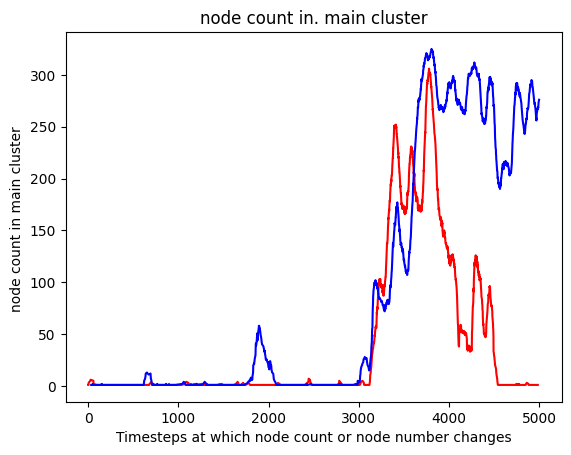

In [10]:
plt.plot(time_df[0],nc_df[0],color='r')
plt.plot(time_df[1],nc_df[1],color='b')
plt.xlabel('Timesteps at which node count or node number changes')
plt.ylabel('node count in main cluster ')
plt.title('node count in. main cluster')

We can also plot node count only above.

Text(0.5, 1.0, 'node count in. main cluster')

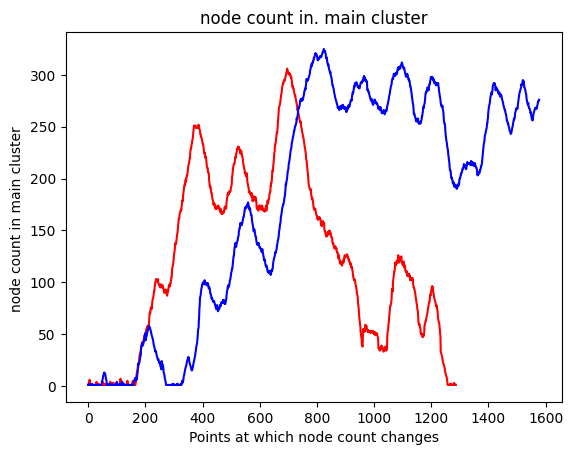

In [11]:

plt.plot(range(0,nc_df[0].shape[0]),nc_df[0],color='r')
plt.plot(range(0,nc_df[1].shape[0]),nc_df[1],color='b')
plt.xlabel('Points at which node count changes')
plt.ylabel('node count in main cluster ')
plt.title('node count in. main cluster')

#### Define the function for overlapping

In [12]:
def plot_nc_overlap(nc_df,name):
    df_check=nc_df.apply(lambda c: c>=100)
    
    set_point = 500
    c=0
    for i in range(0,df_check.shape[1]):
        for val in df_check[i]:
            
            c+=1
            if val == True:
                ts=c
                c=0
                break
        x=list(range(0,nc_df[i].shape[0]))
        
        if ts-1>set_point:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            
            plt.plot(x,nc_df[i].shift(-(ts-set_point)),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        else:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            plt.plot(x,nc_df[i].shift(set_point-ts),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        i+=1
    
    plt.xlabel("timestep")
    plt.ylabel("Node count")
    plt.title(name)
#plt.savefig('../../data/results/PIR_node_count.png')

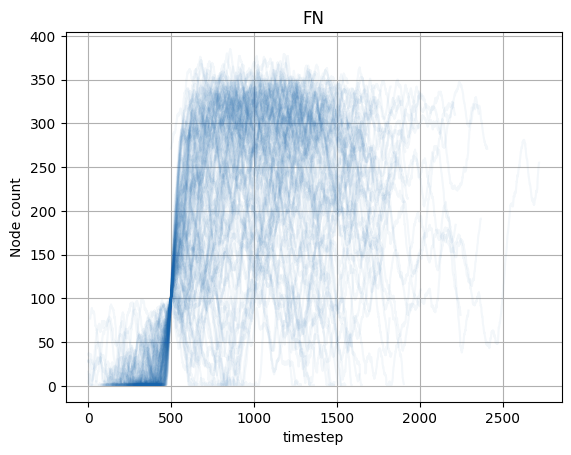

In [13]:
plot_nc_overlap(nc_df,'FN')

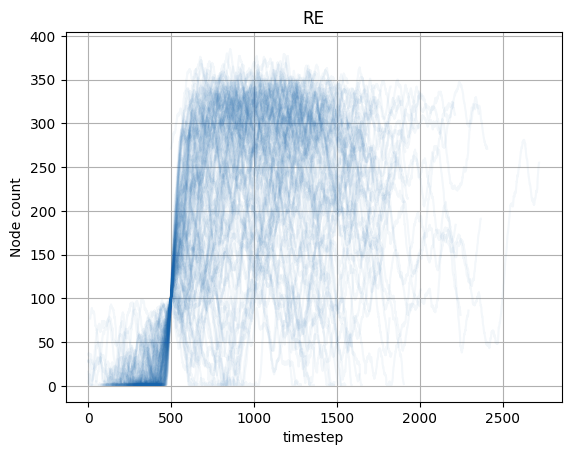

In [14]:
plot_nc_overlap(nc_df,'RE')

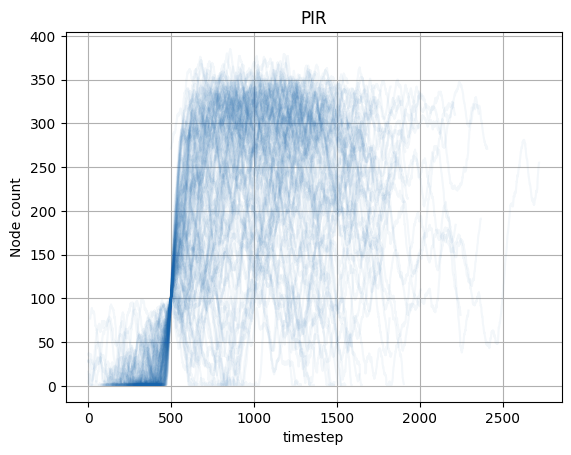

In [15]:
plot_nc_overlap(nc_df,'PIR')

From above, nothing meaningful after overlapping signals

#### Let's try some ML technique if any for identifying the sequence

In [4]:
#let's see if node list is calculated how
#df_nc.loc[2]
nl=analyse.node_count(df_nc.loc[2])
node_list=nl['node_list']


In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

# Example data
lists = node_list

# Transform data for FP-Growth
te = TransactionEncoder()
te_ary = te.fit(lists).transform(lists)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Apply FP-Growth
frequent_itemsets = fpgrowth(df, min_support=0.5, use_colnames=True)

# Print frequent sequences
print(frequent_itemsets)